# **LASSO regression – compound dependence**

This notebook aims to find optimal setting of regularization parameter $\lambda$ AND parameter <code>p</code> (length of the training window). Grid-search concept adopted.

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from DataFramePrep import generate_TrainingDataFrame

# Metrics to measure successfulness
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# ML Stuff
from sklearn.linear_model import Lasso

# In case of convergence problem, supress warning
import warnings

warnings.filterwarnings("ignore")

In [2]:
# Pre-processed data preparation
TrainingDataFrame, tickers, historic_columns, StockDataDatabase = generate_TrainingDataFrame()

# **LASSO regression**

In [3]:
# To track how well predictions work, all metrics -> dominance, MAPE/APE and benchmark performance
performance_trackerENPH = {}

for Alpha in [0.1, 1, 10]:
    for window_length in range(2, 31):
        for ticker in ["ENPH"]:
            # Bounded training-validation set
            Stock_Data = pd.read_sql(
                f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'",
                con=StockDataDatabase, parse_dates=["Date"]
            )
            
            Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
            Stock_Data["Target"] = Stock_Data["Close"]
            Stock_Data = Stock_Data.dropna().reset_index(drop=True)

            # Grid search
            training_length = window_length
            prediction_length = 1

            MAPEs = []

            for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
                # Define feature and target windows
                Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
                Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

                Test_Features = Stock_Data[historic_columns].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]
                Test_Target = Stock_Data["Target"].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]

                # Skip empty slices
                if Training_Features.empty or Test_Features.empty:
                    continue
            
                # Scale only selected features
                scaler = StandardScaler()
                Training_Features = scaler.fit_transform(Training_Features)
                Test_Features = scaler.transform(Test_Features)

                # Fit KNN
                MODEL = Lasso(alpha=Alpha)
                MODEL.fit(Training_Features, Training_Target)

                # Predict and evaluate
                prediction = MODEL.predict(Test_Features)
                MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
            
            # Save results
            performance_trackerENPH[(Alpha, window_length)] = np.mean(MAPEs)
            print((Alpha, window_length), np.mean(MAPEs))


(0.1, 2) 12.997359239933845
(0.1, 3) 5.983556032474575
(0.1, 4) 5.075635387677887
(0.1, 5) 4.9456287242858314
(0.1, 6) 4.936591335569799
(0.1, 7) 4.90254368087127
(0.1, 8) 4.947094292420954
(0.1, 9) 5.0293020495319976
(0.1, 10) 5.066955771701917
(0.1, 11) 5.08042339164837
(0.1, 12) 5.172946766977677
(0.1, 13) 5.219172338475061
(0.1, 14) 5.252770489215189
(0.1, 15) 5.2276340656959
(0.1, 16) 5.3805933614444905
(0.1, 17) 5.420138297002346
(0.1, 18) 5.545556016702903
(0.1, 19) 5.548635214343223
(0.1, 20) 5.555019902352054
(0.1, 21) 5.675287527049449
(0.1, 22) 5.758572318735826
(0.1, 23) 5.821457736950799
(0.1, 24) 5.85785093778322
(0.1, 25) 5.874281501911909
(0.1, 26) 5.862342254310567
(0.1, 27) 5.895821149321202
(0.1, 28) 5.96873639071719
(0.1, 29) 6.037609238756873
(0.1, 30) 6.120972499814951
(1, 2) 8.35086326343782
(1, 3) 5.267169504791749
(1, 4) 5.24341860592138
(1, 5) 5.095935537210534
(1, 6) 5.242518064548819
(1, 7) 5.391458467659633
(1, 8) 5.534617949954949
(1, 9) 5.739773586914624


Text(50.722222222222214, 0.5, '$\\lambda$ regularization')

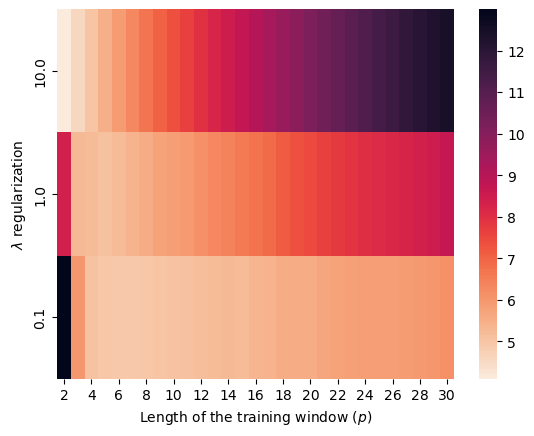

In [4]:
# Heatmap of it
df = pd.Series(performance_trackerENPH).unstack()

sns.heatmap(df, cmap="rocket_r").invert_yaxis()

plt.xlabel("Length of the training window $(p)$")
plt.ylabel("$\lambda$ regularization")

In [ ]:
# Index of argmin
print(np.argmin(list(performance_trackerENPH.values())))

np.int64(34)

Now comes the series of alike visualizations for chosen few stocks.

In [6]:
performance_trackerROP = {}

for Alpha in [0.001, 0.1, 1]:#np.logspace(-4, 2, 50):
    for window_length in range(2, 31):
        for ticker in ["ROP"]:
            Stock_Data = pd.read_sql(
                f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'",
                con=StockDataDatabase, parse_dates=["Date"]
            )
            
            Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
            Stock_Data["Target"] = Stock_Data["Close"]
            Stock_Data = Stock_Data.dropna().reset_index(drop=True)

            training_length = window_length
            prediction_length = 1

            MAPEs = []

            for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
                # Define feature and target windows
                Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
                Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

                Test_Features = Stock_Data[historic_columns].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]
                Test_Target = Stock_Data["Target"].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]

                # Skip empty slices
                if Training_Features.empty or Test_Features.empty:
                    continue
            
                # Scale only selected features
                scaler = StandardScaler()
                Training_Features = scaler.fit_transform(Training_Features)
                Test_Features = scaler.transform(Test_Features)

                # Fit KNN
                MODEL = Lasso(alpha=Alpha)
                MODEL.fit(Training_Features, Training_Target)

                # Predict and evaluate
                prediction = MODEL.predict(Test_Features)
                MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
            
            # Save results
            performance_trackerROP[(Alpha, window_length)] = np.mean(MAPEs)
            print((Alpha, window_length), np.mean(MAPEs))


(0.001, 2) 4.636157096703572
(0.001, 3) 2.6415986054859086
(0.001, 4) 1.9764606144670256
(0.001, 5) 1.8401145313880594
(0.001, 6) 1.727157391927136
(0.001, 7) 1.687745036382142
(0.001, 8) 1.65478338208255
(0.001, 9) 1.6125352986643677
(0.001, 10) 1.6198081010442436
(0.001, 11) 1.6099207630149213
(0.001, 12) 1.6151757427047417
(0.001, 13) 1.638163996559608
(0.001, 14) 1.648769796142733
(0.001, 15) 1.675383700556277
(0.001, 16) 1.6923111836239242
(0.001, 17) 1.711829160742997
(0.001, 18) 1.7334333784377025
(0.001, 19) 1.7649130168041325
(0.001, 20) 1.748198211768169
(0.001, 21) 1.7750534292873494
(0.001, 22) 1.7695675184128952
(0.001, 23) 1.778748113648278
(0.001, 24) 1.790676728938794
(0.001, 25) 1.7736635906187073
(0.001, 26) 1.762935805523223
(0.001, 27) 1.781374990052853
(0.001, 28) 1.8127862255642997
(0.001, 29) 1.8278176686759269
(0.001, 30) 1.8272088691254709
(0.1, 2) 4.431705587539931
(0.1, 3) 2.1907934208746433
(0.1, 4) 1.6415505386054736
(0.1, 5) 1.594080184419278
(0.1, 6) 1.55

Text(50.722222222222214, 0.5, '$\\lambda$ regularization')

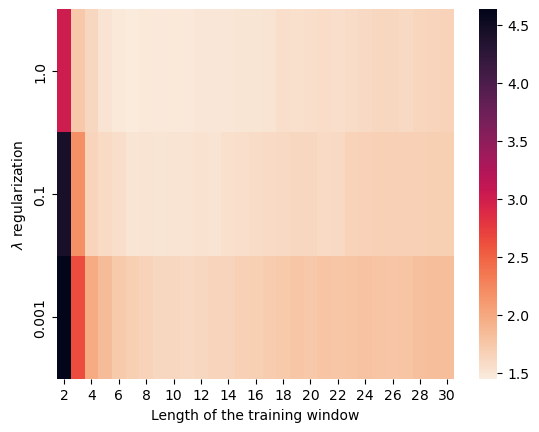

In [7]:
df = pd.Series(performance_trackerROP).unstack()

sns.heatmap(df, cmap="rocket_r").invert_yaxis()

plt.xlabel("Length of the training window")
plt.ylabel("$\lambda$ regularization")

In [8]:
np.argmin(list(performance_trackerROP.values()))

np.int64(63)

In [9]:
performance_trackerSMCI = {}

for Alpha in [0.001, 0.1, 1]:#np.logspace(-4, 2, 50):
    for window_length in range(2, 31):
        for ticker in ["SMCI"]:
            Stock_Data = pd.read_sql(
                f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'",
                con=StockDataDatabase, parse_dates=["Date"]
            )
            
            Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
            Stock_Data["Target"] = Stock_Data["Close"]
            Stock_Data = Stock_Data.dropna().reset_index(drop=True)

            training_length = window_length
            prediction_length = 1

            MAPEs = []

            for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
                # Define feature and target windows
                Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
                Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

                Test_Features = Stock_Data[historic_columns].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]
                Test_Target = Stock_Data["Target"].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]

                # Skip empty slices
                if Training_Features.empty or Test_Features.empty:
                    continue
            
                # Scale only selected features
                scaler = StandardScaler()
                Training_Features = scaler.fit_transform(Training_Features)
                Test_Features = scaler.transform(Test_Features)

                # Fit KNN
                MODEL = Lasso(alpha=Alpha)
                MODEL.fit(Training_Features, Training_Target)

                # Predict and evaluate
                prediction = MODEL.predict(Test_Features)
                MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
            
            # Save results
            performance_trackerSMCI[(Alpha, window_length)] = np.mean(MAPEs)
            print((Alpha, window_length), np.mean(MAPEs))


(0.001, 2) 8.189158640361173
(0.001, 3) 4.064232990967713
(0.001, 4) 3.285969155156579
(0.001, 5) 3.017310277455383
(0.001, 6) 2.9840225841393844
(0.001, 7) 2.8968165928875518
(0.001, 8) 2.9442435699710483
(0.001, 9) 3.0122876826991956
(0.001, 10) 2.985572023391253
(0.001, 11) 3.0472932508404686
(0.001, 12) 3.0702714437149092
(0.001, 13) 3.0924135831915733
(0.001, 14) 3.0991183119744536
(0.001, 15) 3.156688273659856
(0.001, 16) 3.0580195005933413
(0.001, 17) 3.1655853434106502
(0.001, 18) 3.1401832869462862
(0.001, 19) 3.086393982218962
(0.001, 20) 3.1114635349114628
(0.001, 21) 3.1689453096165288
(0.001, 22) 3.1833842695258565
(0.001, 23) 3.186423764002831
(0.001, 24) 3.2362374345360556
(0.001, 25) 3.2482531974323856
(0.001, 26) 3.2624400730681877
(0.001, 27) 3.337159263653708
(0.001, 28) 3.378965689445187
(0.001, 29) 3.4701581246499638
(0.001, 30) 3.519764232558623
(0.1, 2) 2.676056486556715
(0.1, 3) 2.6932895700019546
(0.1, 4) 2.9502196277819697
(0.1, 5) 3.0929756799605164
(0.1, 6) 

Text(50.722222222222214, 0.5, '$\\lambda$ regularization')

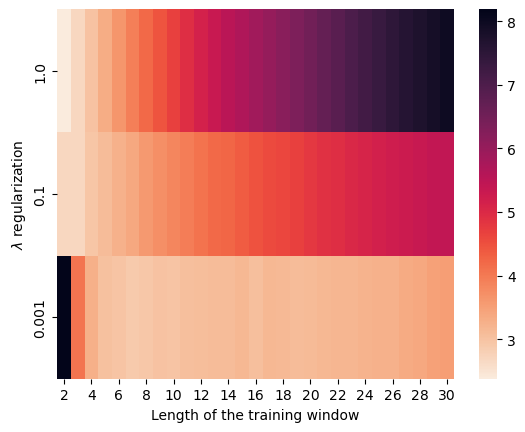

In [10]:
df = pd.Series(performance_trackerSMCI).unstack()

sns.heatmap(df, cmap="rocket_r").invert_yaxis()

plt.xlabel("Length of the training window")
plt.ylabel("$\lambda$ regularization")

In [11]:
np.argmin(list(performance_trackerSMCI.values()))

np.int64(58)

In [12]:
performance_trackerMSI = {}

for Alpha in [0.001, 0.1, 1]:#np.logspace(-4, 2, 50):
    for window_length in range(2, 31):
        for ticker in ["MSI"]:
            Stock_Data = pd.read_sql(
                f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'",
                con=StockDataDatabase, parse_dates=["Date"]
            )
            
            Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
            Stock_Data["Target"] = Stock_Data["Close"]
            Stock_Data = Stock_Data.dropna().reset_index(drop=True)

            training_length = window_length
            prediction_length = 1

            MAPEs = []

            for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
                # Define feature and target windows
                Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
                Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

                Test_Features = Stock_Data[historic_columns].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]
                Test_Target = Stock_Data["Target"].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]

                # Skip empty slices
                if Training_Features.empty or Test_Features.empty:
                    continue
            
                # Scale only selected features
                scaler = StandardScaler()
                Training_Features = scaler.fit_transform(Training_Features)
                Test_Features = scaler.transform(Test_Features)

                # Fit KNN
                MODEL = Lasso(alpha=Alpha)
                MODEL.fit(Training_Features, Training_Target)

                # Predict and evaluate
                prediction = MODEL.predict(Test_Features)
                MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
            
            # Save results
            performance_trackerMSI[(Alpha, window_length)] = np.mean(MAPEs)
            print((Alpha, window_length), np.mean(MAPEs))


(0.001, 2) 5.844876417128449
(0.001, 3) 2.9206190873943045
(0.001, 4) 2.0575579451670962
(0.001, 5) 1.9485510153078274
(0.001, 6) 1.8175468727359256
(0.001, 7) 1.7284236928099481
(0.001, 8) 1.70903268424948
(0.001, 9) 1.7124066386760994
(0.001, 10) 1.689619321104965
(0.001, 11) 1.6745227973223908
(0.001, 12) 1.659535049880782
(0.001, 13) 1.6418925101622168
(0.001, 14) 1.6558102287341097
(0.001, 15) 1.6906004043022016
(0.001, 16) 1.6899090336932554
(0.001, 17) 1.7133009278439826
(0.001, 18) 1.7169601361601754
(0.001, 19) 1.7177565067286584
(0.001, 20) 1.7390360411232402
(0.001, 21) 1.7662075504977368
(0.001, 22) 1.8113306606687076
(0.001, 23) 1.8338541940855462
(0.001, 24) 1.83939522248169
(0.001, 25) 1.848776617264636
(0.001, 26) 1.882617336036072
(0.001, 27) 1.8937435131429645
(0.001, 28) 1.8864685927977012
(0.001, 29) 1.910835238262374
(0.001, 30) 1.9256037881501322
(0.1, 2) 5.366638614684797
(0.1, 3) 2.4163860443546374
(0.1, 4) 1.7886691895618867
(0.1, 5) 1.66192902098571
(0.1, 6) 1

Text(50.722222222222214, 0.5, '$\\lambda$ regularization')

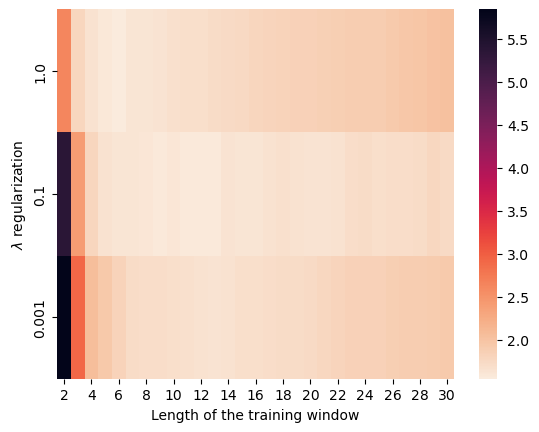

In [13]:
df = pd.Series(performance_trackerMSI).unstack()

sns.heatmap(df, cmap="rocket_r").invert_yaxis()

plt.xlabel("Length of the training window")
plt.ylabel("$\lambda$ regularization")

In [ ]:
performance_trackerENPH_focused = {}

for Alpha in np.arange(4.5, 4.7, 0.01):
    for ticker in ["ENPH"]:
        Stock_Data = pd.read_sql(
            f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'",
            con=StockDataDatabase, parse_dates=["Date"]
        )
            
        Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
        Stock_Data["Target"] = Stock_Data["Close"]
        Stock_Data = Stock_Data.dropna().reset_index(drop=True)

        training_length = 4
        prediction_length = 1

        MAPEs = []

        for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
            # Define feature and target windows
            Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
            Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

            Test_Features = Stock_Data[historic_columns].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]
            Test_Target = Stock_Data["Target"].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]

            # Skip empty slices
            if Training_Features.empty or Test_Features.empty:
                continue
            
            # Scale only selected features
            scaler = StandardScaler()
            Training_Features = scaler.fit_transform(Training_Features)
            Test_Features = scaler.transform(Test_Features)

            # Fit KNN
            MODEL = Lasso(alpha=Alpha)
            MODEL.fit(Training_Features, Training_Target)

            # Predict and evaluate
            prediction = MODEL.predict(Test_Features)
            MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
            
        # Save results
        performance_trackerENPH_focused[Alpha] = np.mean(MAPEs)
        print(Alpha, np.mean(MAPEs))


4.5 4.629486102881529
4.51 4.6287417381488405
4.52 4.627927326101186
4.529999999999999 4.6275154617489624
4.539999999999999 4.626217812778924
4.549999999999999 4.625361189452533
4.559999999999999 4.624513009776796
4.5699999999999985 4.623857823965693
4.579999999999998 4.62362008382021
4.589999999999998 4.62367895678568
4.599999999999998 4.623786232865027
4.609999999999998 4.623981800874499
4.619999999999997 4.624230898864616
4.629999999999997 4.624469147676129
4.639999999999997 4.6246987136215685
4.649999999999997 4.624878151746287
4.659999999999997 4.625066295585858
4.669999999999996 4.625362966438219
4.679999999999996 4.625748921744071
4.689999999999996 4.626167331824126
4.699999999999996 4.626627682456386


Focused view analyzes course of the MAPE on smaller interval of <code>p</code>.

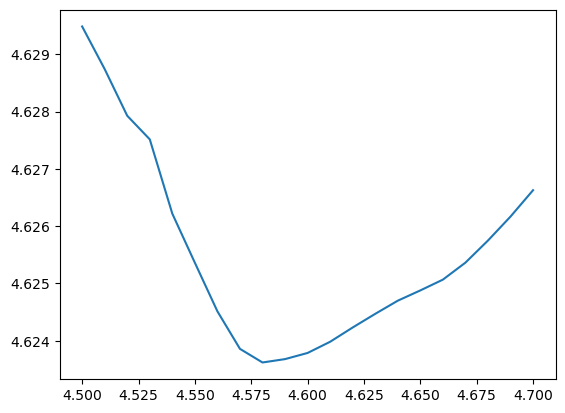

In [15]:
plt.plot(performance_trackerENPH_focused.keys(), performance_trackerENPH_focused.values())